<a href="https://colab.research.google.com/github/BalkeesRekik/DS3001/blob/main/03_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (10000, 28, 28)
(60000,) (10000,)


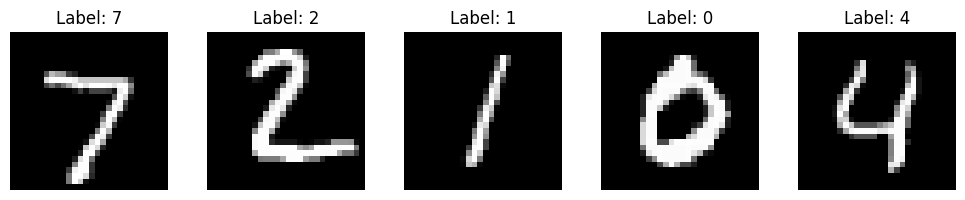

(60000, 784)
(10000, 784)
Accuracy: 0.9705


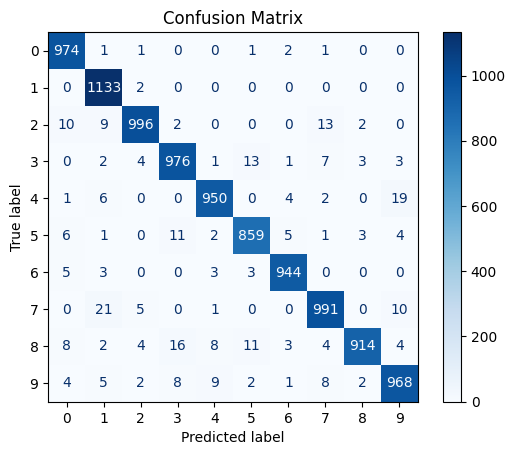

Misclassified examples:


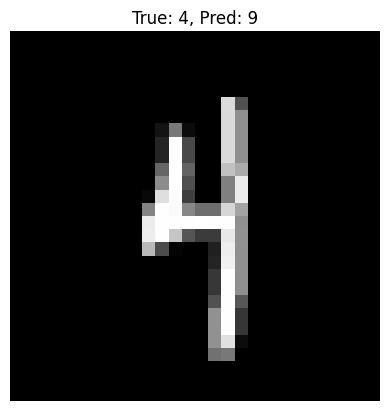

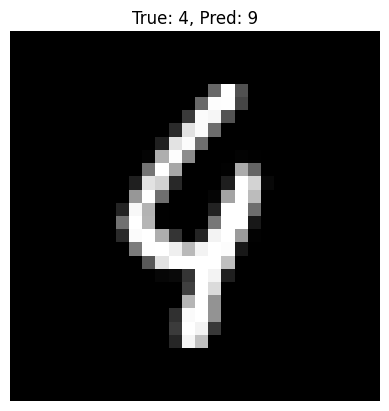

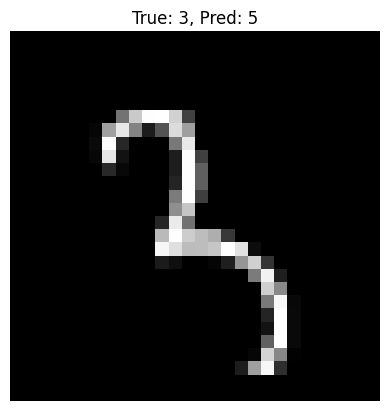

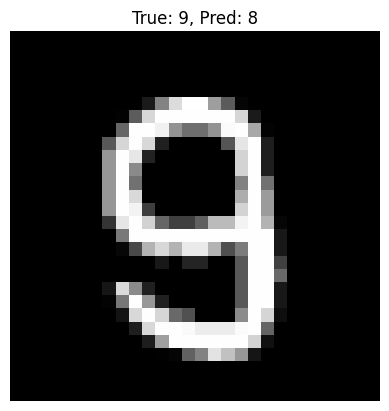

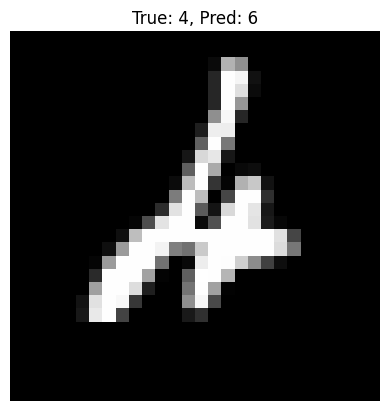

In [1]:
from keras.datasets import mnist
import numpy as np

# Load dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

# Check dimensions
print(train_X.shape, test_X.shape)  # (60000, 28, 28), (10000, 28, 28)
print(train_y.shape, test_y.shape)  # (60000,), (10000,)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(test_X[i], cmap='gray')
    plt.title(f"Label: {test_y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Flatten the images to 1D vectors of length 784
train_X_flat = train_X.reshape(-1, 784)
test_X_flat = test_X.reshape(-1, 784)

print(train_X_flat.shape)  # (60000, 784)
print(test_X_flat.shape)   # (10000, 784)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# You can tune this value later
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(train_X_flat, train_y)

# Predict
pred_y = knn.predict(test_X_flat)

# Accuracy
acc = accuracy_score(test_y, pred_y)
print(f"Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(test_y, pred_y)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print("Misclassified examples:")
misclassified = np.where(test_y != pred_y)[0]
for i in misclassified[:5]:
    plt.imshow(test_X[i], cmap='gray')
    plt.title(f"True: {test_y[i]}, Pred: {pred_y[i]}")
    plt.axis('off')
    plt.show()
